# Module 05 — L-band vs S-band GCOV Comparison

**Files used:**
- `NISAR_L2_PR_GCOV_026_091_D_075_4005_DHDH_A_20260726T123348_20260726T123423_P05023_N_F_J_001.h5` (L-band, track 091/075)
- `NISAR_S2_PR_GCOV_025_141_A_015_3700_DHNA_A_20260717T231346_20260717T231423_P00500_M_F_I_001.h5` (S-band, track 141/015)

**Product / bands:** both GCOV (L2, geocoded covariance), one L-band, one S-band. Different tracks and processing baselines (see `docs/data_inventory.md`), but per Stage 1's automated test (`tests/test_io.py::TestGeocodedCoordinates`), **both are geocoded to the same UTM zone (EPSG:32646) with overlapping x/y grid extents** — confirmed from each file's own `projection`/`xCoordinates`/`yCoordinates` metadata, not assumed. That overlap is what makes this a real apples-to-apples band comparison rather than two arbitrary scenes.

**Region:** northeastern India — Brahmaputra valley (Assam) rising into Meghalaya/Bhutan Himalaya foothills, the same general area as Module 03.

## Scope & Caveats

This notebook demonstrates **reading and visually/quantitatively comparing backscatter from two different radar bands** over the same ground footprint. It is not a validated land-cover or classification study — any band-dependent differences described below are general, textbook SAR properties (how L- and S-band wavelengths tend to interact with vegetation/soil at different scales), not claims about the specific land cover in this scene, which has not been checked against ground truth.

Geographic language is strictly technical (terrain/elevation/backscatter).

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parents[1]
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

SAMPLE_DATA_DIR = REPO_ROOT / "SampleData"

import numpy as np
import matplotlib.pyplot as plt

from nisar_tools.io import open_product
from nisar_tools import preprocess as prep
from nisar_tools import viz

plt.rcParams["figure.dpi"] = 100

In [2]:
GCOV_L_PATH = SAMPLE_DATA_DIR / "NISAR_L2_PR_GCOV_026_091_D_075_4005_DHDH_A_20260726T123348_20260726T123423_P05023_N_F_J_001.h5"
GCOV_S_PATH = SAMPLE_DATA_DIR / "NISAR_S2_PR_GCOV_025_141_A_015_3700_DHNA_A_20260717T231346_20260717T231423_P00500_M_F_I_001.h5"

gcov_l = open_product(GCOV_L_PATH)
gcov_s = open_product(GCOV_S_PATH)

for label, prod in [("L-band (File 3)", gcov_l), ("S-band (File 5)", gcov_s)]:
    coords = prod.coordinates("A")
    print(f"{label}: radar_band={prod.radar_band}  track/frame={prod.track_number}/{prod.frame_number}  "
          f"processingCenter={prod.identification.get('processingCenter')}  CRID={prod.identification.get('compositeReleaseId')}")
    print(f"  EPSG:{coords['epsg']}   x=[{coords['x'].min():.0f}, {coords['x'].max():.0f}]  "
          f"y=[{coords['y'].min():.0f}, {coords['y'].max():.0f}]")
    print(f"  covariance terms: {prod.list_covariance_terms('A')}")

assert gcov_l.coordinates("A")["epsg"] == gcov_s.coordinates("A")["epsg"], "unexpectedly different CRS"
print("\nBoth confirmed in the same CRS with overlapping extents -- proceeding to a shared window.")

L-band (File 3): radar_band=L  track/frame=91/75  processingCenter=JPL  CRID=P05023
  EPSG:32646   x=[219605, 566635]  y=[2787125, 3128395]
  covariance terms: ['HHHH', 'HVHV']
S-band (File 5): radar_band=S  track/frame=141/15  processingCenter=ISRO  CRID=P00500
  EPSG:32646   x=[210965, 553675]  y=[2792165, 3124075]
  covariance terms: ['HHHH', 'HVHV', 'HHHV']

Both confirmed in the same CRS with overlapping extents -- proceeding to a shared window.


## Theory recap

See **Module 00, Sections 2 and 10** for the full explanation. In short: a radar wave interacts most strongly with objects comparable in size to its own wavelength -- shorter-wavelength S-band is more sensitive to fine near-surface structure and penetrates vegetation less deeply than longer-wavelength L-band. Let's compute this dataset's real wavelengths (not textbook numbers) before comparing the two bands' backscatter below.

In [3]:
c = 299_792_458.0
wavelength_l = c / gcov_l.center_frequency("A")
wavelength_s = c / gcov_s.center_frequency("A")
print(f"L-band (File 3) wavelength: {wavelength_l*100:.1f} cm")
print(f"S-band (File 5) wavelength: {wavelength_s*100:.1f} cm  (about {wavelength_l/wavelength_s:.1f}x shorter than L-band)")

L-band (File 3) wavelength: 24.2 cm
S-band (File 5) wavelength: 9.4 cm  (about 2.6x shorter than L-band)


## Selecting a shared ground window

We pick a 20 km x 20 km window in shared UTM-46N coordinates that lies inside both products' confirmed coordinate extents, then use `nisar_tools.preprocess.coordinate_window` to look up each product's *own* row/col indices for that window independently -- the two products have slightly different pixel spacing/origin, so their pixel grids don't line up 1:1, but the same physical ground area is being compared.

In [4]:
WINDOW_X = (360_000, 380_000)
WINDOW_Y = (2_910_000, 2_930_000)

coords_l = gcov_l.coordinates("A")
coords_s = gcov_s.coordinates("A")

row_slice_l, col_slice_l = prep.coordinate_window(coords_l["x"], coords_l["y"], *WINDOW_X, *WINDOW_Y)
row_slice_s, col_slice_s = prep.coordinate_window(coords_s["x"], coords_s["y"], *WINDOW_X, *WINDOW_Y)

print("L-band window shape:", (row_slice_l.stop - row_slice_l.start, col_slice_l.stop - col_slice_l.start))
print("S-band window shape:", (row_slice_s.stop - row_slice_s.start, col_slice_s.stop - col_slice_s.start))

hhhh_l = gcov_l.get_covariance_dataset("HHHH", "A")[row_slice_l, col_slice_l]
hvhv_l = gcov_l.get_covariance_dataset("HVHV", "A")[row_slice_l, col_slice_l]
hhhh_s = gcov_s.get_covariance_dataset("HHHH", "A")[row_slice_s, col_slice_s]
hvhv_s = gcov_s.get_covariance_dataset("HVHV", "A")[row_slice_s, col_slice_s]

extent_l = [coords_l["x"][col_slice_l][0], coords_l["x"][col_slice_l][-1], coords_l["y"][row_slice_l][-1], coords_l["y"][row_slice_l][0]]
extent_s = [coords_s["x"][col_slice_s][0], coords_s["x"][col_slice_s][-1], coords_s["y"][row_slice_s][-1], coords_s["y"][row_slice_s][0]]

L-band window shape: (np.int64(2000), np.int64(2000))
S-band window shape: (np.int64(2000), np.int64(2000))


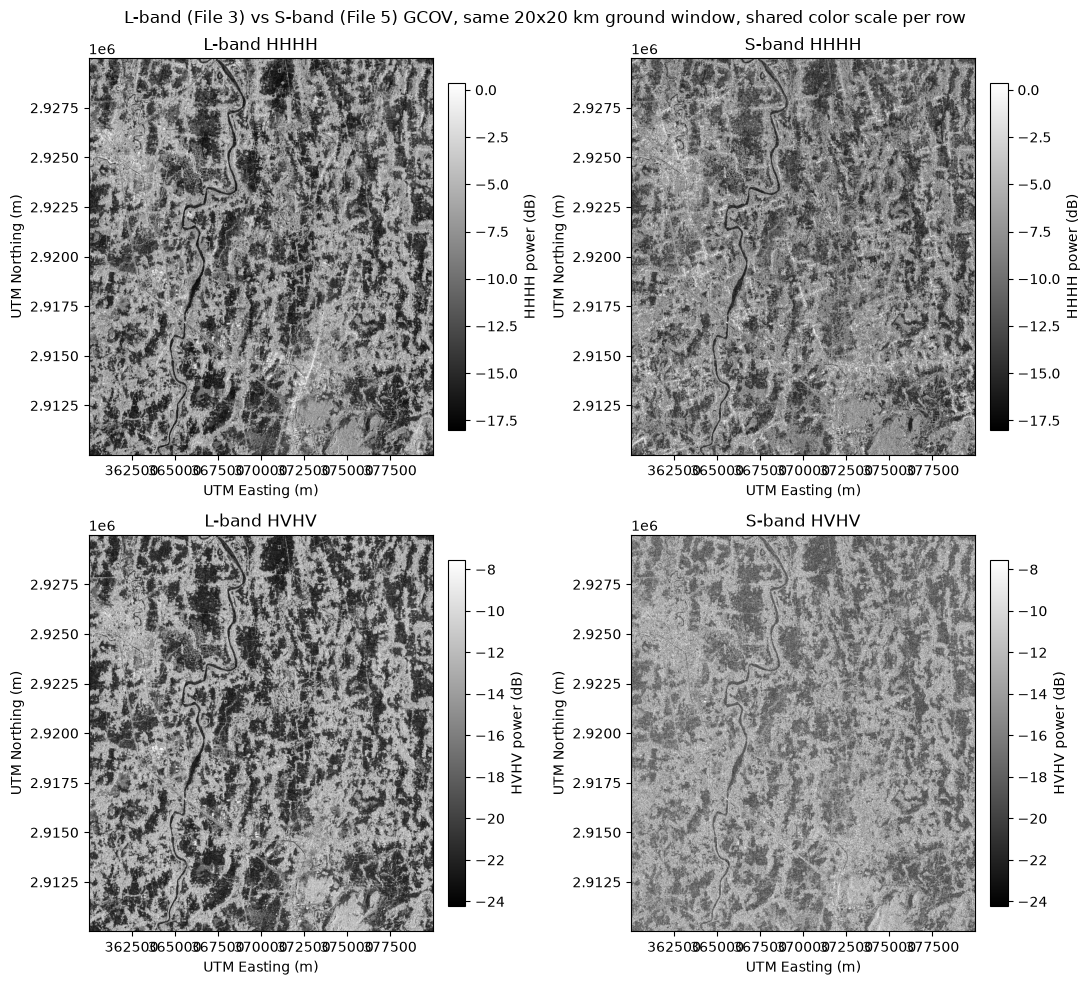

In [5]:
mask_l = np.isfinite(hhhh_l) & np.isfinite(hvhv_l) & (hhhh_l > 0) & (hvhv_l > 0)
mask_s = np.isfinite(hhhh_s) & np.isfinite(hvhv_s) & (hhhh_s > 0) & (hvhv_s > 0)

hhhh_l_db = np.where(mask_l, prep.power_db(hhhh_l), np.nan)
hvhv_l_db = np.where(mask_l, prep.power_db(hvhv_l), np.nan)
hhhh_s_db = np.where(mask_s, prep.power_db(hhhh_s), np.nan)
hvhv_s_db = np.where(mask_s, prep.power_db(hvhv_s), np.nan)

# Shared color scale per polarization channel, so the two bands are visually comparable.
hh_vmin = min(np.nanpercentile(hhhh_l_db, 2), np.nanpercentile(hhhh_s_db, 2))
hh_vmax = max(np.nanpercentile(hhhh_l_db, 98), np.nanpercentile(hhhh_s_db, 98))
hv_vmin = min(np.nanpercentile(hvhv_l_db, 2), np.nanpercentile(hvhv_s_db, 2))
hv_vmax = max(np.nanpercentile(hvhv_l_db, 98), np.nanpercentile(hvhv_s_db, 98))

fig, axes = viz.new_figure(ncols=2, nrows=2, figsize=(11, 10))
viz.imshow_amplitude(axes[0, 0], hhhh_l_db, valid_mask=mask_l, cmap="gray", vmin=hh_vmin, vmax=hh_vmax,
                      extent=extent_l, xlabel="UTM Easting (m)", ylabel="UTM Northing (m)",
                      colorbar_label="HHHH power (dB)", title="L-band HHHH")
viz.imshow_amplitude(axes[0, 1], hhhh_s_db, valid_mask=mask_s, cmap="gray", vmin=hh_vmin, vmax=hh_vmax,
                      extent=extent_s, xlabel="UTM Easting (m)", ylabel="UTM Northing (m)",
                      colorbar_label="HHHH power (dB)", title="S-band HHHH")
viz.imshow_amplitude(axes[1, 0], hvhv_l_db, valid_mask=mask_l, cmap="gray", vmin=hv_vmin, vmax=hv_vmax,
                      extent=extent_l, xlabel="UTM Easting (m)", ylabel="UTM Northing (m)",
                      colorbar_label="HVHV power (dB)", title="L-band HVHV")
viz.imshow_amplitude(axes[1, 1], hvhv_s_db, valid_mask=mask_s, cmap="gray", vmin=hv_vmin, vmax=hv_vmax,
                      extent=extent_s, xlabel="UTM Easting (m)", ylabel="UTM Northing (m)",
                      colorbar_label="HVHV power (dB)", title="S-band HVHV")
fig.suptitle("L-band (File 3) vs S-band (File 5) GCOV, same 20x20 km ground window, shared color scale per row")
fig.tight_layout()
plt.show()

In [6]:
print("Mean backscatter (dB) over the shared window:")
print(f"  L-band HHHH: {np.nanmean(hhhh_l_db):6.2f} dB   L-band HVHV: {np.nanmean(hvhv_l_db):6.2f} dB   "
      f"L-band HH/HV ratio: {np.nanmean(hhhh_l_db) - np.nanmean(hvhv_l_db):5.2f} dB")
print(f"  S-band HHHH: {np.nanmean(hhhh_s_db):6.2f} dB   S-band HVHV: {np.nanmean(hvhv_s_db):6.2f} dB   "
      f"S-band HH/HV ratio: {np.nanmean(hhhh_s_db) - np.nanmean(hvhv_s_db):5.2f} dB")

Mean backscatter (dB) over the shared window:
  L-band HHHH:  -9.36 dB   L-band HVHV: -16.21 dB   L-band HH/HV ratio:  6.85 dB
  S-band HHHH:  -8.98 dB   S-band HVHV: -14.74 dB   S-band HH/HV ratio:  5.77 dB


## Interpreting the band difference

Two things are visible above, and they're different in kind:

- **A quantitative backscatter-level difference** between L- and S-band over the same ground. In general terms (not specific to this unvalidated scene): S-band's shorter wavelength (~9-10 cm vs. L-band's ~24 cm) interacts more with smaller near-surface structure (leaves, small branches, surface roughness at a finer scale) and is typically more sensitive to near-surface soil moisture, while L-band penetrates further into vegetation canopy and can be more sensitive to larger woody structure or, over sparse vegetation, the underlying ground. Which band reads "brighter" for a given target depends on the target's structure at each wavelength's scale — this is a textbook frequency-dependence statement, not a claim about what's driving the specific numbers above.
- **A structural difference in what each file can even represent**: the S-band file additionally has the HHHV off-diagonal covariance term (confirmed above) that this L-band file lacks. That's not a band-physics difference — it's a product-content difference, and it's exactly why Module 06 (which uses this same S-band file) can compute an HH-HV correlation product that Module 03 (this L-band file) explicitly could not.

In [7]:
gcov_l.close()
gcov_s.close()

## What real-world deployment would additionally require

- Radiometric terrain correction/normalization for both products before any quantitative band comparison, since raw backscatter is sensitive to local incidence angle and terrain slope.
- A validated reference (field survey, higher-resolution optical/lidar data) to attribute the observed L vs. S backscatter difference to a specific physical cause (vegetation structure, moisture, roughness) rather than describing it only in general textbook terms as done here.
- Acquisitions closer in time (these two are ~9 days apart, from different tracks/processing baselines) to reduce the chance that temporal change, not just band physics, contributes to the observed difference.
- Consideration of each band's different incidence-angle geometry and native resolution, both of which affect backscatter independently of frequency.